# Machine learning for regression

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-09-01 18:07:35--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.2’

data.csv.2          100%[===================>]   1.41M  --.-KB/s    in 0.03s   

2026-09-01 18:07:35 (49.2 MB/s) - ‘data.csv.2’ saved [1475504/1475504]



# data preparation

In [4]:
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [10]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# Exploratory data analysis

In [11]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

Distribution of price

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

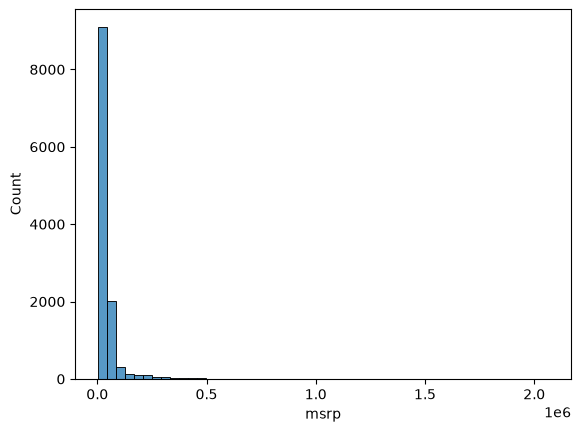

In [13]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

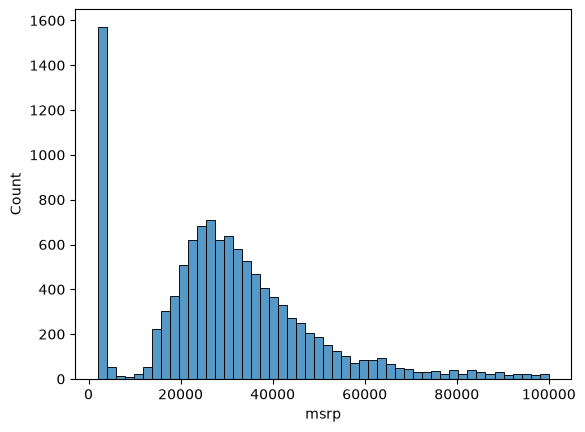

In [14]:
sns.histplot(df.msrp[df.msrp <100000], bins=50)

In [15]:
np.log([0+1,1+1,10+1,1000+1,10000+1]) #add 1 to keep the scale and make sure log(0) error won't happen

array([0.        , 0.69314718, 2.39789527, 6.90875478, 9.21044037])

In [16]:
np.log1p([0,1,10,1000,10000])

array([0.        , 0.69314718, 2.39789527, 6.90875478, 9.21044037])

In [17]:
price_logs = np.log1p(df.msrp)

In [18]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

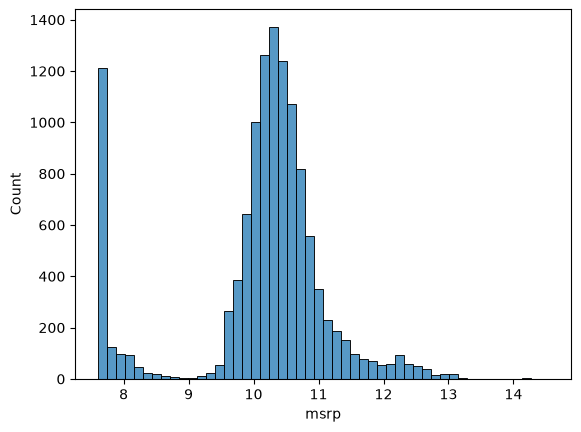

In [19]:
sns.histplot(price_logs, bins=50)

Missing values

In [20]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# setting up the validation framework

In [21]:
#we usually divide the dataset in 60% training, 20% validation, 20% testing
n = len(df)
n_val=n*0.2
n_val

2382.8

In [22]:
n_val=int(n*0.2)#as we want some integers because we cannot make a slide with floats
n_val

2382

In [23]:
n_test=int(n*0.2)
n_train = n-n_val-n_test

In [24]:
n,n_val + n_test+n_train

(11914, 11914)

In [25]:
df.iloc[[10,0,3,5]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,bmw,1_series,2013,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39600
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200


In [26]:
#shuffling the indexes
idx=np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)

In [27]:
df_train=df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_train+n_val:]]

In [28]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [29]:
len(df_train), len(df_test), len(df_val)

(7150, 2382, 2382)

In [30]:
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
1,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
2,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
3,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
4,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
2378,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
2379,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2380,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [31]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [32]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [33]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [34]:
len(y_train)

7150

# linear regression

In [35]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 7557, dtype: object

In [36]:
xi=[453, 11, 86]
w0=7.17
w=[.01,.04,.002]

In [37]:
def linear_regression(xi):
    n = len(xi)
    pred=w0

    for j in range(n):
        pred=pred+w[j]*xi[j]
    return pred

In [38]:
pred = linear_regression(xi)
pred

12.312

In [39]:
np.expm1(pred) #same as np.exp(pred)-1 to sustract the +1 added earlier

np.float64(222347.2221101062)

# Linear Regression Vector Form

In [40]:
def dot(xi, w):
    n=len(xi)
    res = 0.0
    for j in range(n):
        res=res+xi[j]*w[j]
    return res


In [41]:
def linear_regression(xi):
    return w0 + dot(xi,w)

In [42]:
w_new=[w0]+w

In [43]:
def linear_regression(xi):
    xi=[1]+xi
    return dot(xi, w_new)

In [44]:
linear_regression(xi)

12.312

In [45]:
w0=7.17
w=[.01,.04,.002]
w_new= [w0] + w

In [46]:
x1=[1,453, 11, 86]
x2=[1,148,24,1385]
x10=[1,453,11,86]

X = [x1,x2,x10]
X = np.array(X)
X

array([[   1,  453,   11,   86],
       [   1,  148,   24, 1385],
       [   1,  453,   11,   86]])

In [47]:
def linear_regression(X):
    return X.dot(w_new)


# training linear regression model normal equation

In [90]:
def train_linear_regression(X,y):
    pass


In [102]:
X = [
    [453, 11, 86],
    [148,24,1385],
    [453,11,86],
    [158, 24, 185],
    [172,25,201],
    [413,11,86],
    [38, 54, 185],
    [142,25,431],
    [453,31,86],
]

X = np.array(X)
X

array([[ 453,   11,   86],
       [ 148,   24, 1385],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [92]:
ones=np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [93]:
X = np.column_stack([ones, X])

In [103]:
y=[10000,20000,15000,25000,10000,20000,15000,25000,12000]

In [95]:
XTX=X.T.dot(X)

In [96]:
XTX_inv = np.linalg.inv(XTX)

In [97]:
w_full = XTX_inv.dot(X.T).dot(y)

In [98]:
w0 = w_full[0]
w = w_full[1:]

In [99]:
w0,w

(np.float64(30017.21833253469),
 array([ -27.29239206, -246.60841278,    0.52470336]))

In [303]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX=X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [105]:
train_linear_regression(X,y)

(np.float64(30017.21833253469),
 array([ -27.29239206, -246.60841278,    0.52470336]))

# car price baseline model

In [108]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [110]:
base = ['engine_hp','engine_cylinders','highway_mpg','popularity']

In [113]:
X_train=df_train[base].values

In [115]:
df_train.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        1
engine_hp              40
engine_cylinders       14
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      2251
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
dtype: int64

In [ ]:
X_train=df_train[base].fillna(0).values #if there are nan values the result will be nan as well

In [125]:
w0, w=train_linear_regression(X_train, y_train)

In [126]:
y_pred = w0+X_train.dot(w)

<Axes: ylabel='Count'>

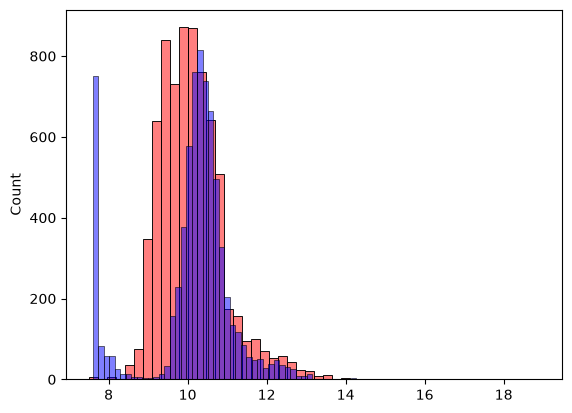

In [127]:
sns.histplot(y_pred, color='red', alpha= 0.5, bins = 50)
sns.histplot(y_train, color='blue', alpha  =0.5, bins=50)

# RMSE

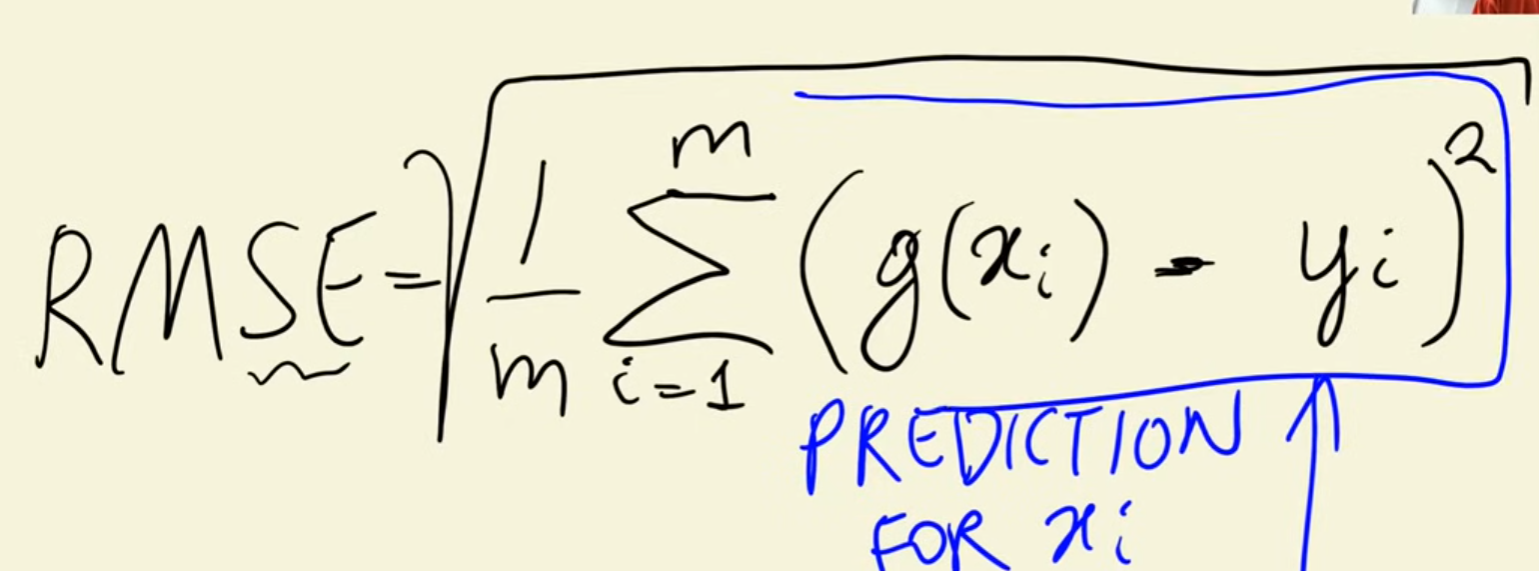

In [132]:
def rmse(y, y_pred): 
    se = (y-y_pred)**2
    mse = se.mean()
    return np.sqrt(mse)


In [133]:
rmse(y_train, y_pred)

np.float64(0.7585356196570802)

# Validating the model

In [168]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg', 'popularity']
X_train=df_train[base].fillna(0).values #if there are nan values the result will be nan as well
w0, w=train_linear_regression(X_train, y_train)
y_pred = w0+X_train.dot(w)



In [169]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X=df_num.values
    return X


In [170]:
#train
X_train = prepare_X(df_train)
w0, w=train_linear_regression(X_train,y_train)
#val
X_val=prepare_X(df_val)
y_pred=w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.761653099130156)

# simple featuure engineering

In [171]:
2017-df_train.year

2735      9
6720      5
5878      1
11190    26
4554      0
         ..
434       2
1902      2
9334      2
5284      3
2420      0
Name: year, Length: 7150, dtype: int64

In [178]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base+['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X=df_num.values
    
    return X


In [179]:
X_train = prepare_X(df_train)

In [180]:
X_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 2.200e+01, 1.700e+01, 5.490e+02, 2.000e+00],
       [5.630e+02, 1.200e+01, 2.100e+01, 1.300e+01, 8.600e+01, 3.000e+00],
       [2.000e+02, 4.000e+00, 3.100e+01, 2.200e+01, 8.730e+02, 0.000e+00]],
      shape=(7150, 6))

In [182]:
#train
X_train = prepare_X(df_train)
w0, w=train_linear_regression(X_train,y_train)

y_pred=w0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

#val
X_val=prepare_X(df_val)
y_pred=w0+ X_val.dot(w)
print('val',rmse(y_val, y_pred))

train 0.5175055465840046
val 0.5172055461058299


<Axes: ylabel='Count'>

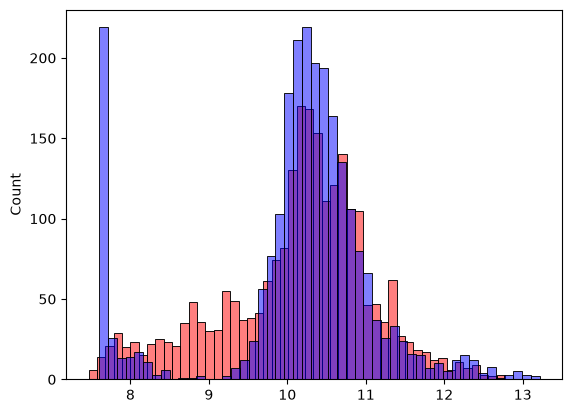

In [184]:
sns.histplot(y_pred, color='red', alpha= 0.5, bins = 50)
sns.histplot(y_val, color='blue', alpha  =0.5, bins=50)

# categorical variables

In [187]:
df_train.number_of_doors

2735     2.0
6720     4.0
5878     4.0
11190    3.0
4554     4.0
        ... 
434      2.0
1902     2.0
9334     4.0
5284     4.0
2420     4.0
Name: number_of_doors, Length: 7150, dtype: float64

In [198]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1


In [223]:
makes=list(df.make.value_counts().head().index)

In [224]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base+['age']
    
    for v in [2,3,4]:
        df['num_doors_%s'%v] = (df.number_of_doors==v).astype('int')
        features.append('num_doors_%s'%v)
    
    for v in makes:
        df['make_%s'%v] = (df.make==v).astype('int')
        features.append('make_%s'%v)


    df_num = df[features]
    df_num = df_num.fillna(0)
    X=df_num.values
    
    return X


In [225]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   0.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   1.,   0.],
       [148.,   4.,  37., ...,   0.,   0.,   0.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   0.],
       [563.,  12.,  21., ...,   0.,   0.,   0.],
       [200.,   4.,  31., ...,   1.,   0.,   0.]], shape=(7150, 14))

In [226]:
#train
X_train = prepare_X(df_train)
w0, w=train_linear_regression(X_train,y_train)

y_pred=w0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

#val
X_val=prepare_X(df_val)
y_pred=w0+ X_val.dot(w)
print('val',rmse(y_val, y_pred))

train 0.5058876515487503
val 0.5076038849556795


In [248]:
df_train.dtypes[df_train.dtypes == 'str'].index

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='str')

In [251]:
categorical_variables = ['make', 'engine_fuel_type', 'transmission_type','driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']

In [252]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

In [ ]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base+['age']
    
    for v in [2,3,4]:
        df['num_doors_%s'%v] = (df.number_of_doors==v).astype('int')
        features.append('num_doors_%s'%v)
        
    for c, values in categories.items():
        for v in values:
            df['%s_%s'%(c,v)] = (df[c]==v).astype('int')
            features.append('%s_%s'%(c,v))


    df_num = df[features]
    df_num = df_num.fillna(0)
    X=df_num.values
    
    return X


In [ ]:
#train
X_train = prepare_X(df_train)
w0, w=train_linear_regression(X_train,y_train)

y_pred=w0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

#val
X_val=prepare_X(df_val)
y_pred=w0+ X_val.dot(w)
rmse(y_val, y_pred))

train 35.63386933735464


np.float64(23.019020704791835)

In [260]:
w0,w

(np.float64(4011091003551887.0),
 array([ 5.17477261e-02,  5.87434156e+00,  2.58988500e+00, -9.14739385e-01,
         3.29434090e-03,  1.26747065e+00,  1.09365186e+03,  1.08197230e+03,
         1.08519232e+03, -2.94630727e+00, -7.48076191e+00,  1.02357603e+01,
        -8.56657044e-01, -2.27736086e+00,  1.84973907e+00, -3.51656880e+00,
        -2.20958315e+00,  6.07018281e+00, -3.32427158e+01, -4.60060984e+15,
        -4.60060984e+15, -4.60060984e+15, -4.60060984e+15, -4.60060984e+15,
         5.89518839e+14,  5.89518839e+14,  5.89518839e+14,  5.89518839e+14,
        -9.26775404e-01,  3.51631589e-01,  1.80584944e-01,  1.46169331e+00,
        -1.67201746e+00, -3.59104780e+00, -6.16304692e+00, -5.45706022e+00,
        -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
        -1.64412078e-01]))

# Regularization

In [267]:
X = [
    [4,4,4],
    [3,5,5],
    [5,1,1],
    [5,4,4],
    [7,5,5],
    [4,5,5.0000001],
]

X = np.array(X)
X

array([[4.       , 4.       , 4.       ],
       [3.       , 5.       , 5.       ],
       [5.       , 1.       , 1.       ],
       [5.       , 4.       , 4.       ],
       [7.       , 5.       , 5.       ],
       [4.       , 5.       , 5.0000001]])

In [276]:
y=[1,2,3,1,2,3]

In [277]:
XTX = X.T.dot(X)
XTX

array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [278]:
XTX_inv=np.linalg.inv(XTX)
XTX_inv

array([[ 3.92646538e-02, -1.54615164e+05,  1.54615121e+05],
       [-1.54615170e+05,  3.51843724e+13, -3.51843721e+13],
       [ 1.54615129e+05, -3.51843721e+13,  3.51843718e+13]])

In [279]:
XTX_inv.dot(X.T).dot(y)

array([ 2.73776578e-01, -4.41093100e+06,  4.41093113e+06])

In [296]:
XTX = [
    [1,2,2],
    [2,1,1.0000001],
    [2,1.0000001,1]
]

XTX = np.array(XTX)

In [297]:
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [300]:
XTX = XTX + 0.01*np.eye(3)

In [301]:
np.linalg.inv(XTX)

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [305]:
def train_linear_regression_reg(X,y, r=0.001):
    ones=np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX=X.T.dot(X)
    XTX = XTX + r* np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]


In [311]:
#train
X_train = prepare_X(df_train)
w0, w=train_linear_regression_reg(X_train,y_train, r=0.00001)

y_pred=w0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

#val
X_val=prepare_X(df_val)
y_pred=w0+ X_val.dot(w)
rmse(y_val, y_pred)

train 0.4602097255820107


np.float64(0.45651702823445617)

# Tuning the model

In [313]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w=train_linear_regression_reg(X_train,y_train, r=r)

    X_val=prepare_X(df_val)
    y_pred=w0+ X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0.0 4011091003551887.0 23.019020704791835
1e-05 6.178192055025445 0.45651702823445617
0.0001 6.317246071243372 0.4565170654323052
0.001 6.285636717989048 0.45651750867781377
0.1 6.1912087238544915 0.4565692763007501
1 5.634896668066369 0.457220431799306
10 4.283980108968471 0.4701456932099909


In [314]:
r=0.001

X_train = prepare_X(df_train)
w0, w=train_linear_regression_reg(X_train,y_train, r=r)

X_val=prepare_X(df_val)
y_pred=w0+ X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.45651750867781377)

# Using the model

In [316]:
df_full_train = pd.concat([df_train, df_val])

In [318]:
df_fuull_train = df_full_train.reset_index(drop=True)

In [319]:
X_full_train=prepare_X(df_full_train)

In [320]:
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [322]:
y_full_train = np.concatenate([y_train,y_val])

In [323]:
w0, w=train_linear_regression_reg(X_full_train,y_full_train, r=0.001)

In [326]:
X_test = prepare_X(df_test)
y_pred = w0+ X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.4517749310621406)

In [330]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [334]:
df_small=pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [335]:
X_small = prepare_X(df_small)

In [338]:
y_pred = w0+ X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.462651700289744)

In [339]:
np.expm1(y_pred)

np.float64(34983.19616272936)

In [341]:
np.expm1(y_test[20])

np.float64(35000.00000000001)